# Classifying Irises
This notebook has missing code after the first few cells. See if you can fill in the code using the classifying-penguins.ipynb file, documentation, other notebooks, ChatGPT (or other generative AI tool), or the classifying-irises.ipynb notebook at https://github.com/JohnMcKechnieGC/supervised-and-unsupervised-ml/blob/main/classifying-irises.ipynb

First we'll import numpy, Matplotlib and everything we need from Scikit-learn.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

The Scikit-learn functions we'll use in this notebook employ the random number generator from NumPy. Seeding the random number generator is optional. Doing so means that we'll get the same results every time we run the notebook which might be convenient. The number 0 is often used as a seed, as is 42 (a reference to The Hitchhiker's Guide to the Galaxy by Douglas Adams), but any seed will ensure that the random number generator produces a consistent sequence of numbers.

In [2]:
np.random.seed(0)

Now we'll get the dataset.

The variable names X (uppercase) and y (lowercase) are often used in machine learning. X denotes the features, in this case 4-dimensional vectors for each iris: petal length, petal width, sepal length, and sepal width. The variable y denotes the label assigned to each feature vector, in this case the species of iris. It is the fact that we have these labels that makes this a demo of supervised machine learning. Unsupervised machine learning does not rely on the availability of labels.

In [3]:
X, y = load_iris(as_frame=True, return_X_y=True)

Let's see the first five rows to get an idea of what our iris data looks like.

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


The species labels stored in an array where 0 = setosa, 1 = versicolor, and 2 = 'virginica'.

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

After we build our models, we'll want to evaluate them. It would be cheating to evaluate a model using the same data that we used to build it. We really want to know how well the model does on new data that it hasn't seen before. Here we divide the dataset into training and test data. We'll use 70% of the data to build the model (X_train and y_train) and 30% of the data to test the model (X_test and y_test). The train_text_split function that we imported makes this easy.

Machine learning practitioners can be inconsistent in their use of terminology. I'm using the terms 'training set' and 'test set' here, which is common and is consistent with the function name 'train_test_split'. But you'll also hear the term 'validation set'. When people use this they are often using the following definitions (which are also common so you need to know about them):
- training set: the data used to build the model
- validation set: the data used optimise the model (see: https://github.com/JohnMcKechnieGC/ensemble-methods/blob/main/hyperparameter_tuning.ipynb)
- test set: the data used to finally evaluate the model after optimisation

There are other ways to partition a dataset, e.g. using cross-validation which you can explore. For now we'll stick with the simple idea that we build a model with one portion of the data and evaluate it with the other.

## Decision tree classifier
Decision trees are not as accurate as some other types of model (we'll compare with random forests shortly), but a single decision tree is easier to examine and interpret. Here we build and plot a decision tree. This will enable us to see that the petal length and petal width features are more useful for this classification task.

First we create a DecisionTreeClassifier object. There are some parameters that might affect the size of the tree and how it is built. We can experiment with these.

We now create our decision tree by fitting the training data.

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",25
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",25
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the cur

The plot_tree function lets us inspect the decision tree.

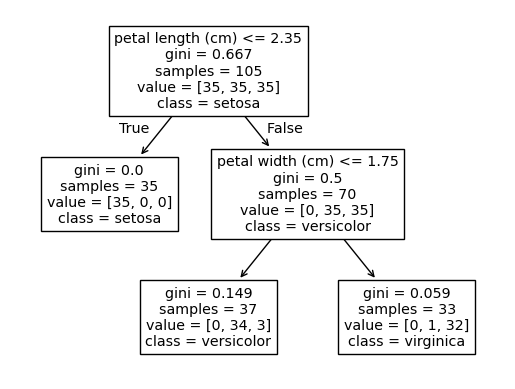

We can use our decision tree to predict the class of all irises in the test set.

There are three species of iris, so each prediction is either 0, 1, or 2 (setosa = 0, versicolor = 1, and virginica = 2).

array([2, 2, 0, 0, 1, 0, 1, 2, 0, 1, 0, 2, 0, 2, 1, 1, 1, 1, 1, 0, 1, 2,
       0, 1, 1, 2, 2, 2, 1, 2, 1, 0, 0, 1, 1, 2, 1, 0, 0, 1, 0, 2, 0, 0,
       2])

We now evaluate the accuracy of the decision tree by comparing the model's predictions with the actual labels in the test set. Accuracy is defined as: number of correct predictions / number of predictions made.

We now evaluate the accuracy of the decision tree by comparing the model's predictions with the actual labels in the test set. Accuracy is defined as: number of correct predictions / number of predictions made.

Tree accuracy: 0.9555555555555556
